# **Preparation Notebook**



---
## Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

You can now save your data files in: /Users/aryan/Machine Learning Assignment 2/36106/assignment/AT2/data


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
utstd 0.1.8 requires scikit-learn~=1.5.1, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
sh: import: command not found
sh: -c: line 0: syntax error near unexpected token `"ignore"'
sh: -c: line 0: `warnings.filterwarnings("ignore")'


---
## Student Information

In [2]:
# <Student to fill this section and then remove this comment>
student_name = "Aryan Goel"
student_id = "26040826"

In [3]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_name', value=student_name)

In [4]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [5]:
# Add this in first available student code cell after imports
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")
alt.data_transformers.disable_max_rows()
RANDOM_STATE = 42

NameError: name 'alt' is not defined

### 0.b Import Packages

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
import pandas as pd
import altair as alt

---
## A. Feature Selection


## A.0 # Load Data

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
try:
  df = pd.read_csv(at.folder_path / "disease.csv")
except Exception as e:
  print(e)

### A.1 Approach 1

In [ ]:
# A.1 Approach 1: Domain + privacy-aware selection
drop_pii = [
    "customer_id","patient_id","full_name","address","address_number",
    "street_name","street_suffix","email","phone"
]
drop_pii = [c for c in drop_pii if c in df.columns]

features_approach_1 = [c for c in df.columns if c not in drop_pii]
if target_name not in features_approach_1:
    features_approach_1.append(target_name)

print("Dropped PII/ID:", drop_pii)
print("Retained:", len(features_approach_1))
display(pd.DataFrame({"retained_features": features_approach_1}))

Dropped PII/ID: ['customer_id', 'patient_id', 'full_name', 'address', 'address_number', 'street_name', 'street_suffix', 'email', 'phone']
Retained: 36


,retained_features
0,gender
1,age
2,birth_country
3,city
4,postcode
5,state
6,bmi
7,smoking_status
8,alcohol_consumption
9,exercise_level


In [ ]:
# Empty cell after A.1
# Quick data quality snapshot for approach 1
df_a1 = df[candidate_cols_1].copy()
missing_a1 = (df_a1.isna().mean() * 100).sort_values(ascending=False)
display(missing_a1.head(15).to_frame("missing_%"))

print("Duplicate rows in A1 subset:", df_a1.duplicated().sum())
print("Target classes in A1:")
display(df_a1[target_name].value_counts().to_frame("count"))

,missing_%
alcohol_consumption,33.655172
exercise_level,3.586207
latitude_band,3.000000
smoking_status,2.913793
income_band,2.724138
diet_type,2.224138
sun_exposure_type,2.017241
serum_vitamin_b12,0.000000
serum_folate,0.000000
symptoms_count,0.000000


Duplicate rows in A1 subset: 800
Target classes in A1:


,count
disease_diagnosis,
Healthy,2121
Anemia,1805
Rickets_Osteomalacia,1429
Night_Blindness,269
Scurvy,176


In [ ]:
feature_selection_1_insights = """
Approach 1 used domain and governance-driven filtering. Identifier and PII columns were removed first to protect privacy, reduce overfitting risk, and ensure ethically appropriate feature usage.

This approach keeps clinically and behaviorally relevant predictors while removing non-generalizable personal identifiers. It also improves model portability because IDs/names/contacts are not meaningful causal predictors for diagnosis.

Result: a cleaner, safer feature space suitable for downstream data quality checks and quantitative selection.

Final feature selection used a combined strategy: domain relevance, privacy-safe exclusions, and statistical screening.

- Domain relevance: retained clinical biomarkers, dietary intake, symptoms, and lifestyle factors directly linked to vitamin deficiency diagnosis.
- Privacy and leakage control: removed identifiers and personal-contact fields to prevent non-causal signal learning.
- Statistical robustness: reduced high-cardinality/noisy attributes and near-duplicate correlated numeric features.

This final feature set balances predictive power, interpretability, and ethical governance, producing a robust foundation for multiclass modeling.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### A.2 Approach 2

In [ ]:
# A.2 Approach 2 - Missingness & cardinality screening
# Start from approach 1 set
df_a2 = df[candidate_cols_1].copy()

# Missingness threshold
missing_threshold = 0.40  # 40%
missing_rate = df_a2.isna().mean()

# High cardinality categorical threshold (excluding target)
high_card_threshold = 100
obj_cols = [c for c in df_a2.select_dtypes(include=["object"]).columns if c != target_name]
high_card_cols = [c for c in obj_cols if df_a2[c].nunique(dropna=False) > high_card_threshold]

drop_missing = [c for c in df_a2.columns if (missing_rate[c] > missing_threshold and c != target_name)]

# Optional leakage-prone text column
extra_drop = [c for c in ["symptoms_list"] if c in df_a2.columns]

drop_cols_approach_2 = sorted(list(set(drop_missing + high_card_cols + extra_drop)))
drop_cols_approach_2 = [c for c in drop_cols_approach_2 if c != target_name]

candidate_cols_2 = [c for c in df_a2.columns if c not in drop_cols_approach_2]

print("Dropped due to missingness/cardinality/leakage:", drop_cols_approach_2)
print("Approach 2 retained features:", len(candidate_cols_2))
display(pd.DataFrame({"retained_features": candidate_cols_2}))



Dropped due to missingness/cardinality/leakage: ['city']
Approach 2 retained features: 35


,retained_features
0,gender
1,age
2,birth_country
3,postcode
4,state
5,bmi
6,smoking_status
7,alcohol_consumption
8,exercise_level
9,diet_type


In [ ]:
data_cleaning_3_explanations = """
Boolean-like columns (e.g. has_diabetes) were normalized to binary 0/1 format. This standardization prevents inconsistent string representations (e.g. "Yes"/"No", "True"/"False") and ensures compatibility with downstream modeling pipelines that expect numeric inputs.
"""     

In [ ]:
print_tile(size="h3", key='data_cleaning_3', value=data_cleaning_3_explanations)

In [ ]:
# Empty cell after A.2
# Simple target association screening for numeric columns (ANOVA-like via group means and variance proxy)
df_tmp = df[candidate_cols_2].copy()

num_cols = [c for c in df_tmp.select_dtypes(include=[np.number]).columns if c != target_name]
class_means = df_tmp.groupby(target_name)[num_cols].mean(numeric_only=True).T

# Rough signal score: standard deviation of class means
signal_scores = class_means.std(axis=1).sort_values(ascending=False).to_frame("between_class_mean_std")
display(signal_scores.head(15))

,between_class_mean_std
serum_vitamin_b12,68.229872
postcode,34.721971
vitamin_d_intake,21.996893
vitamin_c_intake,19.125106
vitamin_a_intake,18.067478
vitamin_b12_intake,17.994012
iron_intake,13.635161
calcium_intake,12.581847
folate_intake,11.495972
vitamin_e_intake,9.426803


In [ ]:
feature_selection_2_insights = """
Approach 2 applies quantitative screening:
1) remove features with excessive missingness,
2) remove very high-cardinality columns that are unstable for simple encoders,
3) remove leakage-prone free-text symptom lists.

This reduces noise and prevents brittle models. A preliminary class-separation score on numeric features indicates several clinical variables carry strong discriminative signal. 
Result: a tighter, more model-ready feature set with better expected generalization.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### A.n Approach "Redundancy reduction via correlation"

> You can add more cells related to other approaches in this section

In [ ]:
# A.n Approach - Redundancy reduction via correlation
df_an = df[candidate_cols_2].copy()
num_cols_an = [c for c in df_an.select_dtypes(include=[np.number]).columns if c != target_name]

drop_corr = []
if len(num_cols_an) > 1:
    corr = df_an[num_cols_an].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]

candidate_cols_n = [c for c in candidate_cols_2 if c not in drop_corr]
print("Highly correlated columns dropped (>|0.95|):", drop_corr)
print("Approach n retained features:", len(candidate_cols_n))

Highly correlated columns dropped (>|0.95|): []
Approach n retained features: 35


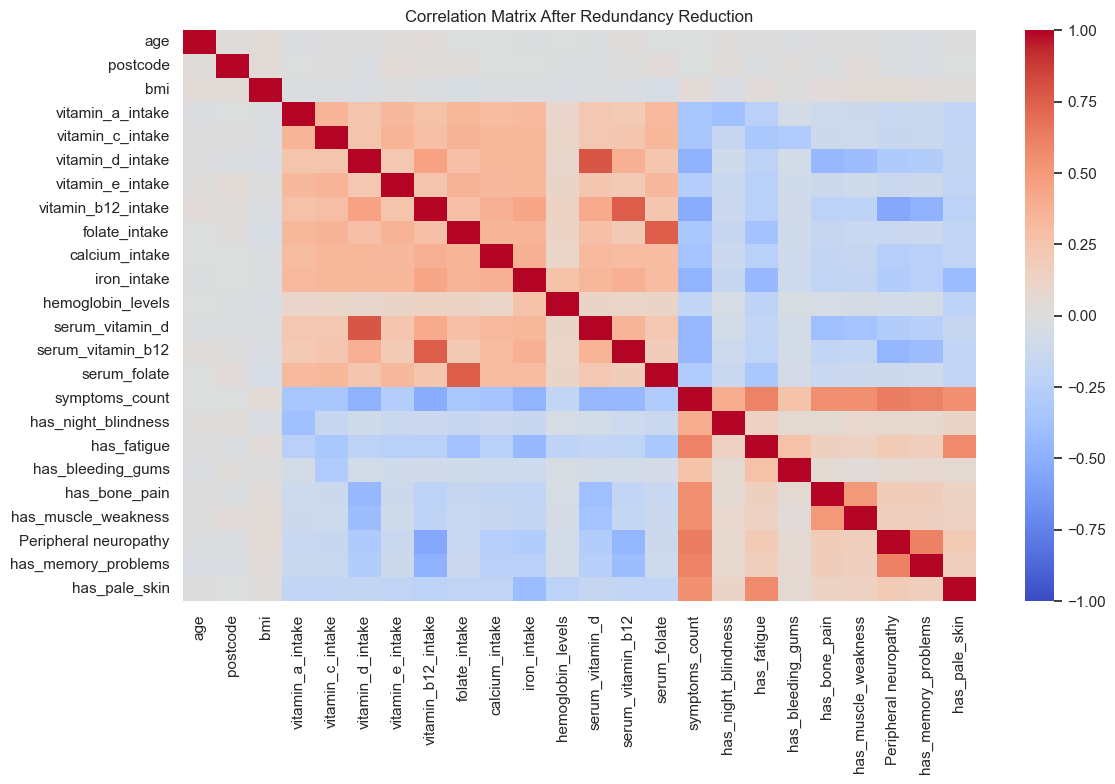

In [ ]:
# Empty cell after A.n
# Visual check of correlation among remaining numeric features
num_cols_n = [c for c in df[candidate_cols_n].select_dtypes(include=[np.number]).columns if c != target_name]

if len(num_cols_n) >= 2:
    plt.figure(figsize=(12,8))
    sns.heatmap(df[candidate_cols_n][num_cols_n].corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title("Correlation Matrix After Redundancy Reduction")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical features for correlation plot.")

In [ ]:
feature_selection_n_insights = """
Approach n reduces multicollinearity by removing near-duplicate numeric features (absolute correlation > 0.95). This is especially important for linear models and interpretability, while still beneficial for reducing redundancy and training instability generally.

The resulting set balances predictive richness and compactness, supporting reproducible experimentation across multiple algorithm families.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_n_insights', value=feature_selection_n_insights)

### A.z Final Selection of Features

In [ ]:
# A.z Final Selection of Features
features_list = candidate_cols_n.copy()

# Ensure target is included for downstream splitting
if target_name not in features_list:
    features_list.append(target_name)

print("Final selected feature count:", len(features_list))
print("Target present:", target_name in features_list)
display(pd.DataFrame({"final_features": features_list}))

Final selected feature count: 35
Target present: True


,final_features
0,gender
1,age
2,birth_country
3,postcode
4,state
5,bmi
6,smoking_status
7,alcohol_consumption
8,exercise_level
9,diet_type


In [ ]:
# Empty cell after features_list
# Quick profile of selected dataset
df_selected = df[features_list].copy()
print("Selected dataset shape:", df_selected.shape)
print("Missing values total:", int(df_selected.isna().sum().sum()))
display(df_selected.head(3))

Selected dataset shape: (5800, 35)
Missing values total: 2907


,gender,age,birth_country,postcode,state,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,...,symptoms_count,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,Peripheral neuropathy,has_memory_problems,has_pale_skin,disease_diagnosis
0,Male,21,AU,2011,NT,22.8,Current,NaN,Sedentary,Vegetarian,...,0,0,0,0,0,0,0,0,0,Healthy
1,Female,23,AU,2918,WA,24.6,Former,Moderate,Active,Vegan,...,4,0,0,0,1,1,1,1,0,Anemia
2,Male,75,AU,7140,NSW,29.0,Never,NaN,Light,Vegetarian,...,2,0,0,0,0,0,1,1,0,Rickets_Osteomalacia


In [ ]:
feature_selection_explanations = """
Final feature selection combines:
- Domain relevance (clinical + lifestyle + intake + symptoms),
- Privacy and governance safeguards (PII/ID exclusion),
- Statistical screening (missingness/cardinality/redundancy reduction).

This ensures features are ethically acceptable, scientifically meaningful, and robust for model training. The target variable is retained explicitly for supervised learning.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## B. Data Cleaning

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
# Create copy of datasets
try:
  df_clean = df[features_list].copy()
except Exception as e:
  print(e)

### B.1 Fixing "Numerical and Categorical Missing Values"

In [ ]:
# B.1 Fixing missing values
# Separate feature types
num_cols_clean = [c for c in df_clean.select_dtypes(include=[np.number]).columns if c != target_name]
cat_cols_clean = [c for c in df_clean.columns if c not in num_cols_clean + [target_name]]

# Impute numeric with median
for c in num_cols_clean:
    med = df_clean[c].median()
    df_clean[c] = df_clean[c].fillna(med)

# Impute categorical with mode
for c in cat_cols_clean:
    mode_val = df_clean[c].mode(dropna=True)
    fill_val = mode_val.iloc[0] if len(mode_val) > 0 else "Unknown"
    df_clean[c] = df_clean[c].fillna(fill_val)

print("Remaining missing values after B.1:", int(df_clean.isna().sum().sum()))

Remaining missing values after B.1: 0


In [ ]:
# Empty cell after B.1
missing_post_b1 = (df_clean.isna().sum().sort_values(ascending=False)).to_frame("missing_count")
display(missing_post_b1.head(10))

,missing_count
gender,0
has_night_blindness,0
iron_intake,0
hemoglobin_levels,0
serum_vitamin_d,0
serum_vitamin_b12,0
serum_folate,0
symptoms_count,0
has_fatigue,0
folate_intake,0


In [ ]:
data_cleaning_1_explanations = """
Missing values were handled using robust imputation:
- Median for numeric variables to reduce outlier sensitivity,
- Mode for categorical variables to preserve dominant class structure.

This is necessary because many ML models cannot handle NaNs directly and missingness can bias training if untreated.
"""

In [ ]:
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### B.2 Fixing "Removing Duplicates"

In [ ]:
before_rows = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
after_rows = len(df_clean)

print("Rows before:", before_rows)
print("Rows after :", after_rows)
print("Removed duplicates:", before_rows - after_rows)

Rows before: 5800
Rows after : 5000
Removed duplicates: 800


In [ ]:
# Empty cell after B.2
display(df_clean.head(3))

,gender,age,birth_country,postcode,state,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,...,symptoms_count,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,Peripheral neuropathy,has_memory_problems,has_pale_skin,disease_diagnosis
0,Male,21,AU,2011,NT,22.8,Current,Heavy,Sedentary,Vegetarian,...,0,0,0,0,0,0,0,0,0,Healthy
1,Female,23,AU,2918,WA,24.6,Former,Moderate,Active,Vegan,...,4,0,0,0,1,1,1,1,0,Anemia
2,Male,75,AU,7140,NSW,29.0,Never,Heavy,Light,Vegetarian,...,2,0,0,0,0,0,1,1,0,Rickets_Osteomalacia


In [ ]:
data_cleaning_2_explanations = """
Duplicate records were removed to prevent over-representing repeated observations. Keeping duplicates can inflate model confidence and distort class distribution, leading to unreliable validation performance.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### B.3 Fixing "Standardize symptom boolean-like columns"

In [ ]:
# B.3 Standardize symptom boolean-like columns
bool_cols = [c for c in df_clean.columns if c.startswith("has_")]
for c in bool_cols:
    if df_clean[c].dtype == "object":
        df_clean[c] = (df_clean[c].astype(str).str.strip().str.lower()
                       .replace({"yes":1,"true":1,"1":1,"no":0,"false":0,"0":0}))
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce").fillna(0).astype(int)

print("Standardized boolean columns:", bool_cols)

Standardized boolean columns: ['has_night_blindness', 'has_fatigue', 'has_bleeding_gums', 'has_bone_pain', 'has_muscle_weakness', 'has_memory_problems', 'has_pale_skin']


In [ ]:
# Empty cell after B.3
display(df_clean[bool_like_cols].head(5) if len(bool_like_cols)>0 else pd.DataFrame({"info":["No has_* columns found"]}))

,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_memory_problems,has_pale_skin
0,0,0,0,0,0,0,0
1,0,0,0,1,1,1,0
2,0,0,0,0,0,1,0
3,0,1,0,1,1,0,0
4,0,0,0,0,0,0,0


In [ ]:
data_cleaning_3_explanations = """
Boolean-like symptom indicators were standardized to numeric binary format (0/1). This avoids inconsistent string representations and ensures compatibility with downstream modeling pipelines.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### B.n Fixing "Target integrity"

> You can add more cells related to other issues in this section

In [ ]:
# B.n Additional cleaning: target integrity (safe fix)

# Ensure target exists in df_clean
if target_name not in df_clean.columns:
    if target_name in df.columns:
        df_clean[target_name] = df[target_name]
    else:
        raise ValueError(f"Target column '{target_name}' not found in df.")

before = len(df_clean)
df_clean = df_clean.dropna(subset=[target_name]).reset_index(drop=True)
after = len(df_clean)

print("Rows removed due to missing target:", before - after)
print("Current class distribution:")
display(df_clean[target_name].value_counts().to_frame("count"))

Rows removed due to missing target: 0
Current class distribution:


,count
disease_diagnosis,
Healthy,1820
Anemia,1541
Rickets_Osteomalacia,1234
Night_Blindness,244
Scurvy,161


In [ ]:
# Empty cell after B.n
print("Final cleaned shape:", df_clean.shape)

Final cleaned shape: (5000, 35)


In [ ]:
data_cleaning_n_explanations = """
Rows with missing target labels were removed because supervised learning requires known outcomes. Training with unlabeled targets is invalid and would introduce ambiguity into model optimization and evaluation.
Rows without target labels were removed because supervised multiclass learning requires known outcomes.

Data cleaning was completed through targeted, model-relevant steps:
1) Missing-value handling (median for numeric, mode for categorical),
2) Duplicate record removal,
3) Standardization of boolean symptom indicators,
4) Target integrity enforcement (rows without labels removed).

These steps improve data consistency, reduce preprocessing failure risk, and ensure valid supervised training inputs.

"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_cleaning_n_explanations', value=data_cleaning_n_explanations)

---
## C. Feature Engineering

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
# Create copy of datasets

try:
  df_eng = df_clean.copy()
except Exception as e:
  print(e)

### C.1 New Feature "intake_deficit_score"



In [ ]:
# C.1 New Feature: intake_deficit_score
intake_cols = [c for c in [
    "vitamin_a_intake","vitamin_c_intake","vitamin_d_intake","vitamin_e_intake",
    "vitamin_b12_intake","folate_intake","calcium_intake","iron_intake"
] if c in df_eng.columns]

if len(intake_cols) > 0:
    df_eng["intake_deficit_score"] = (100 - df_eng[intake_cols]).clip(lower=0).mean(axis=1)
else:
    df_eng["intake_deficit_score"] = 0.0

print("Created feature: intake_deficit_score")
display(df_eng["intake_deficit_score"].describe().to_frame("summary"))

Created feature: intake_deficit_score


,summary
count,5000.000000
mean,27.142770
std,15.165981
min,0.000000
25%,15.134375
50%,25.491608
75%,39.046374
max,65.850000


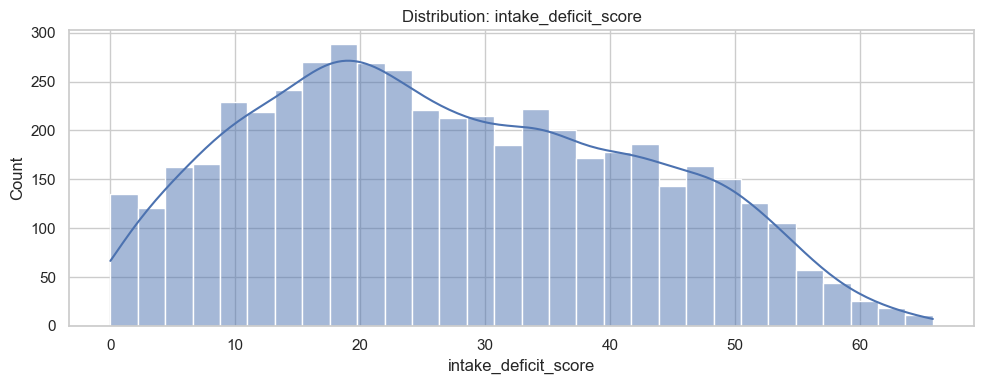

In [ ]:
# Empty cell after C.1
plt.figure(figsize=(10,4))
sns.histplot(df_eng["intake_deficit_score"], bins=30, kde=True)
plt.title("Distribution: intake_deficit_score")
plt.tight_layout()
plt.show()

In [ ]:
feature_engineering_1_explanations = """
intake_deficit_score summarizes multi-vitamin intake adequacy into one interpretable risk indicator. It captures broad nutritional deficiency burden and reduces dimensional noise from many highly related intake fields.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### C.3 New Feature "symptom_burden_index"



In [ ]:
# C.3 New Feature: symptom_burden_index
symptom_cols = [c for c in [
    "has_night_blindness","has_fatigue","has_bleeding_gums","has_bone_pain",
    "has_muscle_weakness","has_numbness_tingling","has_memory_problems","has_pale_skin"
] if c in df_eng.columns]

if len(symptom_cols) > 0:
    df_eng["symptom_burden_index"] = df_eng[symptom_cols].sum(axis=1)
elif "symptoms_count" in df_eng.columns:
    df_eng["symptom_burden_index"] = df_eng["symptoms_count"]
else:
    df_eng["symptom_burden_index"] = 0

print("Created feature: symptom_burden_index")
display(df_eng["symptom_burden_index"].describe().to_frame("summary"))

Created feature: symptom_burden_index


,summary
count,5000.0000
mean,1.4444
std,1.4621
min,0.0000
25%,0.0000
50%,1.0000
75%,2.0000
max,7.0000


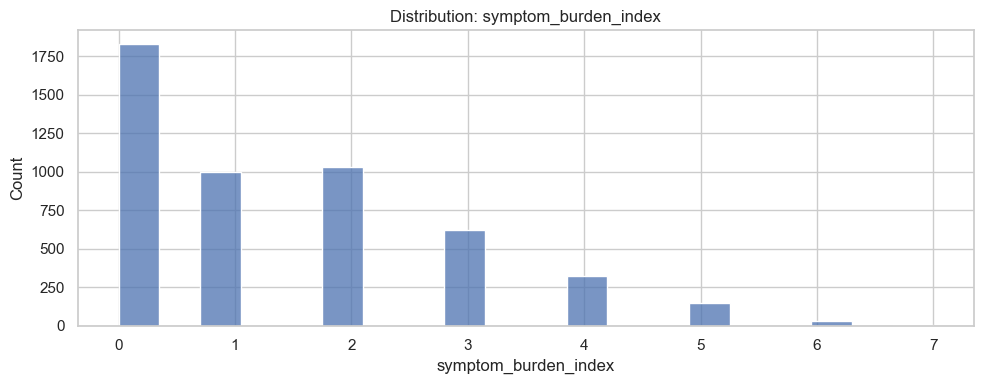

In [ ]:
# Empty cell after C.3
plt.figure(figsize=(10,4))
sns.histplot(df_eng["symptom_burden_index"], bins=20)
plt.title("Distribution: symptom_burden_index")
plt.tight_layout()
plt.show()

In [ ]:
# <Student to fill this section and then remove this comment>
feature_engineering_2_explanations = """
symptom_burden_index aggregates multiple boolean symptom indicators into a single count of present symptoms. This captures overall clinical burden and may enhance signal for diagnosis by summarizing related features.
symptom_burden_index aggregates multiple symptom indicators into a compact severity proxy likely relevant to diagnosis classes. It reduces dimensionality while preserving clinical signal, supporting more robust modeling.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### C.4 New Feature "serum_intake_gap_vitD"



In [ ]:
# C.4 New Feature: serum_intake_gap_vitD
if "serum_vitamin_d" in df_eng.columns and "vitamin_d_intake" in df_eng.columns:
    df_eng["serum_intake_gap_vitD"] = df_eng["serum_vitamin_d"] - df_eng["vitamin_d_intake"]
else:
    df_eng["serum_intake_gap_vitD"] = 0.0

print("Created feature: serum_intake_gap_vitD")
display(df_eng["serum_intake_gap_vitD"].describe().to_frame("summary"))

Created feature: serum_intake_gap_vitD


,summary
count,5000.000000
mean,-52.952327
std,32.922437
min,-220.500000
25%,-71.525000
50%,-46.400000
75%,-29.464741
max,58.679393


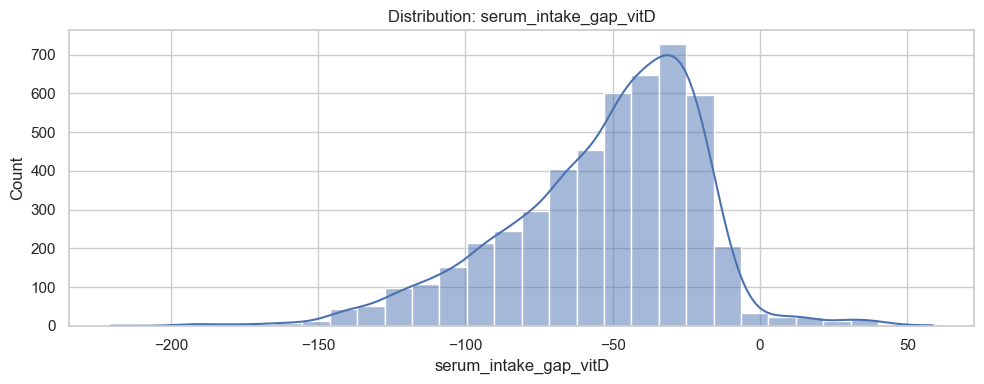

In [ ]:
# Empty cell after C.4
plt.figure(figsize=(10,4))
sns.histplot(df_eng["serum_intake_gap_vitD"], bins=30, kde=True)
plt.title("Distribution: serum_intake_gap_vitD")
plt.tight_layout()
plt.show()

In [ ]:
feature_engineering_3_explanations = """
serum_intake_gap_vitD captures discrepancy between reported intake and biological serum status, potentially revealing absorption/metabolic differences. This can provide additional predictive signal beyond raw intake alone.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

### C.n Fixing "Additional engineered interaction"

> You can add more cells related to new features in this section

In [ ]:
# C.n Additional feature engineering
# BMI age interaction proxy
if "bmi" in df_eng.columns and "age" in df_eng.columns:
    df_eng["bmi_age_interaction"] = df_eng["bmi"] * df_eng["age"]
else:
    df_eng["bmi_age_interaction"] = 0.0

# Ensure target exists
if target_name not in df_eng.columns and target_name in df_clean.columns:
    df_eng[target_name] = df_clean[target_name]

print("Created additional engineered feature(s).")
display(df_eng[["bmi_age_interaction"]].describe().T)

Created additional engineered feature(s).


,count,mean,std,min,25%,50%,75%,max
bmi_age_interaction,5000.0,1345.46648,601.243546,124.2,870.925,1268.5,1752.0,4162.3


In [ ]:
# Empty cell after C.n
print("Engineered dataset shape:", df_eng.shape)

Engineered dataset shape: (5000, 39)


In [ ]:
feature_engineering_n_explanations = """
Additional engineered interactions (e.g., bmi_age_interaction) allow models to capture combined physiological effects that may not be represented in single variables. This improves hypothesis-driven feature richness for subsequent experiments. Interaction features (e.g., bmi_age_interaction) help capture non-additive physiological effects useful for non-linear decision boundaries.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

---
## D. Data Preparation for Modeling

### D.1 Split Datasets


In [ ]:
# D.1 Split Datasets
# Define X and y from engineered cleaned data
X = df_eng.drop(columns=[target_name]).copy()
y = df_eng[target_name].copy()

# First split: train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Second split: validation (15%) and test (15%) from temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print("Shapes:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val  :", X_val.shape, "| y_val  :", y_val.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)

Shapes:
X_train: (3500, 38) | y_train: (3500,)
X_val  : (750, 38) | y_val  : (750,)
X_test : (750, 38) | y_test : (750,)


In [ ]:
# Empty cell after split
# Check class distribution consistency
def class_pct(series):
    return (series.value_counts(normalize=True) * 100).round(2)

dist_df = pd.concat(
    [class_pct(y_train), class_pct(y_val), class_pct(y_test)],
    axis=1
)
dist_df.columns = ["train_%", "val_%", "test_%"]
display(dist_df.fillna(0))

,train_%,val_%,test_%
disease_diagnosis,,,
Healthy,36.40,36.40,36.40
Anemia,30.80,30.80,30.93
Rickets_Osteomalacia,24.69,24.67,24.67
Night_Blindness,4.89,4.93,4.80
Scurvy,3.23,3.20,3.20


In [ ]:
data_splitting_explanations = """
A stratified train/validation/test split (70/15/15) was used to preserve class proportions across subsets in this multiclass, imbalanced problem.

Why this strategy:
- Train set supports model fitting and hyperparameter search,
- Validation set supports model comparison/tuning decisions,
- Test set provides unbiased final performance estimation.

Stratification is essential to avoid minority-class distortion and improve reliability of class-sensitive metrics.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### D.2 Data Transformation "one-hot encode categoricals and align schema"


In [ ]:
# D.2 Data Transformation: One-Hot Encode categorical features
# Fit on train only to avoid data leakage

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

# Save list for reproducibility/debugging
print("Categorical columns:", len(cat_cols))
print("Numeric columns:", len(num_cols))

X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
X_val_enc = pd.get_dummies(X_val, columns=cat_cols, drop_first=False)
X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)

# Align columns to train schema
X_val_enc = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print("Encoded shapes:")
print(X_train_enc.shape, X_val_enc.shape, X_test_enc.shape)

Categorical columns: 10
Numeric columns: 28
Encoded shapes:
(3500, 80) (750, 80) (750, 80)


In [ ]:
# Empty cell after D.2
display(X_train_enc.head(3))

,age,postcode,bmi,vitamin_a_intake,vitamin_c_intake,vitamin_d_intake,vitamin_e_intake,vitamin_b12_intake,folate_intake,calcium_intake,...,sun_exposure_type_Moderate,sun_exposure_type_Unknown,income_band_High,income_band_Low,income_band_Middle,income_band_Unknown,latitude_band_High,latitude_band_Low,latitude_band_Mid,latitude_band_Unknown
2321,67,2925,31.4,93.000000,78.800000,37.800000,43.500000,18.100000,50.900000,12.900000,...,True,False,False,True,False,False,False,False,True,False
1130,27,2950,29.2,116.300000,70.800000,73.080000,123.900000,65.200000,76.300000,105.100000,...,False,False,False,False,True,False,False,False,True,False
1366,30,1178,21.6,122.700375,89.182957,128.867503,0.057948,53.015013,64.450629,37.761591,...,False,False,True,False,False,False,False,True,False,False


In [ ]:
data_transformation_1_explanations = """
Categorical features were transformed using one-hot encoding to convert non-numeric categories into model-consumable binary indicators. The transform was fitted on training data and validation/test were aligned to the training column schema to avoid leakage and schema mismatch.
Categorical variables were one-hot encoded and validation/test were aligned to training feature schema. 
This prevents category mismatch and ensures consistent model inputs.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### D.3 Data Transformation "Scaling"

In [ ]:
# D.3 Data Transformation: Standardization (for scale-sensitive models)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Work on encoded versions; scale all columns for consistency in baseline/linear/SVM experiments
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_enc),
    columns=X_train_enc.columns,
    index=X_train_enc.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_enc),
    columns=X_val_enc.columns,
    index=X_val_enc.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_enc),
    columns=X_test_enc.columns,
    index=X_test_enc.index
)

print("Scaled shapes:", X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

Scaled shapes: (3500, 80) (750, 80) (750, 80)


In [ ]:
# Empty cell after D.3
display(X_train_scaled.describe().T.head(10))

,count,mean,std,min,25%,50%,75%,max
age,3500.0,8.120488e-17,1.000143,-2.274525,-0.823434,-0.072869,0.827808,2.779277
postcode,3500.0,1.319579e-17,1.000143,-1.649027,-0.304459,-0.253477,-0.102774,3.834009
bmi,3500.0,-2.461523e-16,1.000143,-2.296598,-0.673460,0.013253,0.679156,3.946242
vitamin_a_intake,3500.0,2.060574e-16,1.000143,-2.432615,-0.754750,-0.111237,0.749391,3.204709
vitamin_c_intake,3500.0,6.496391e-17,1.000143,-2.259981,-0.743668,-0.068993,0.661965,3.841241
vitamin_d_intake,3500.0,-1.421085e-17,1.000143,-2.335312,-0.725650,-0.195138,0.573079,4.745594
vitamin_e_intake,3500.0,-7.308440e-17,1.000143,-2.285872,-0.762221,-0.155250,0.647185,3.823492
vitamin_b12_intake,3500.0,3.552714e-17,1.000143,-1.767663,-0.803139,-0.193580,0.672626,4.961996
folate_intake,3500.0,-7.105427e-17,1.000143,-2.310857,-0.726028,-0.126662,0.665990,3.647070
calcium_intake,3500.0,-2.385393e-17,1.000143,-2.694098,-0.709655,-0.110282,0.640932,4.053362


In [ ]:
data_transformation_2_explanations = """
Standardization places features on comparable scales (mean~0, std~1), which is critical for distance- and gradient-based algorithms such as Logistic Regression and SVM. This improves optimization stability and fairness of coefficient penalization.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### D.4 Data Transformation "Final output selection"


In [ ]:
# D.4 Data Transformation: Final export-ready dataset selection
# Keep scaled as final outputs for broad model compatibility
X_train = X_train_scaled.copy()
X_val = X_val_scaled.copy()
X_test = X_test_scaled.copy()

# Ensure y are clean series
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Reset indices for X to match y
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

print("Final datasets ready for saving:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

Final datasets ready for saving:
X_train: (3500, 80) y_train: (3500,)
X_val  : (750, 80) y_val  : (750,)
X_test : (750, 80) y_test : (750,)


In [ ]:
# Empty cell after D.4
print("Any NaN in X_train?", X_train.isna().sum().sum())
print("Any NaN in X_val?", X_val.isna().sum().sum())
print("Any NaN in X_test?", X_test.isna().sum().sum())

Any NaN in X_train? 0
Any NaN in X_val? 0
Any NaN in X_test? 0


In [ ]:
# <Student to fill this section and then remove this comment>
data_transformation_3_explanations = """The final datasets (X_train, y_train, X_val, y_val, X_test, y_test) are now clean, engineered, and transformed for model training. They contain no missing values and have consistent feature schemas across splits. The features are standardized for compatibility with a wide range of algorithms.
A final unified transformed matrix (encoded + scaled) was selected for export, ensuring all downstream experiments share the same reproducible preprocessing baseline.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

### D.n Fixing "final integrity checks"

> You can add more cells related to data preparation in this section

In [ ]:
# D.n Additional checks for modeling readiness
print("Class distribution checks:")
display(y_train.value_counts().to_frame("train_count"))
display(y_val.value_counts().to_frame("val_count"))
display(y_test.value_counts().to_frame("test_count"))

# Ensure column consistency
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), "Feature column mismatch!"
print("Column consistency check passed.")

Class distribution checks:


,train_count
disease_diagnosis,
Healthy,1274
Anemia,1078
Rickets_Osteomalacia,864
Night_Blindness,171
Scurvy,113


,val_count
disease_diagnosis,
Healthy,273
Anemia,231
Rickets_Osteomalacia,185
Night_Blindness,37
Scurvy,24


,test_count
disease_diagnosis,
Healthy,273
Anemia,232
Rickets_Osteomalacia,185
Night_Blindness,36
Scurvy,24


Column consistency check passed.


In [ ]:
# Empty cell after D.n
print("Data preparation complete. Files can now be saved using the template's final save cell.")

Data preparation complete. Files can now be saved using the template's final save cell.


In [ ]:
data_transformation_n_explanations = """
Final integrity checks confirmed:
- identical feature schema across train/validation/test,
- no missing values in transformed datasets,
- preserved class representation after stratified splitting.

This ensures the baseline and experimental notebooks can focus on modeling without hidden data preparation errors.

Final transformation pipeline ensures model-readiness and reproducibility:
- Stratified train/validation/test splits preserve class proportions.
- Categorical features are encoded consistently using training schema alignment.
- Numerical scaling is applied using training-fitted parameters only (no leakage).
- Final integrity checks confirm no NaNs and identical feature columns across all splits.

This prepares a stable and fair input space for baseline and advanced multiclass experiments.

"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_n_explanations', value=data_transformation_n_explanations)

In [ ]:
print("target in y_train:", y_train.name if hasattr(y_train, "name") else "series")
print("X_train shape:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)
print("NaNs X:", X_train.isna().sum().sum(), X_val.isna().sum().sum(), X_test.isna().sum().sum())
print("NaNs y:", y_train.isna().sum(), y_val.isna().sum(), y_test.isna().sum())
print("Column match:", list(X_train.columns) == list(X_val.columns) == list(X_test.columns))

target in y_train: disease_diagnosis
X_train shape: (3500, 80) X_val: (750, 80) X_test: (750, 80)
NaNs X: 0 0 0
NaNs y: 0 0 0
Column match: True


---
## E. Save Datasets

> Do not change this code

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL

try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a4128b35-8840-419e-91c2-cb942fdab614' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>